# Kv2.1 L403A: all-distance sampling breadth at equal depth

This notebook expands the S6-focused sampling analysis to every exact shared numerical distance in the established `all_ok_rmsd_3A_structural_interface_alignment_qc` vanilla and masked L403A tables: 705 Cα distances and 705 shortest-heavy-atom distances.

It asks whether masking broadens the complete precomputed distance ensemble, whether that effect is already visible in the first 1,000 retained structures, and how closely early results reproduce complete-QC results.

## Statistical design

Rows are ordered deterministically by seed, model number, and recycle; this is an indexed equal-depth analysis, not timestamped wall-clock chronology. Global IQR ratios describe the complete distributions. For inference, an IQR is calculated within each seed for every distance, making seed—not recycle snapshot—the statistical unit. Vanilla and masked seed-IQR distributions are compared with two-sided Mann–Whitney tests followed by Benjamini–Hochberg FDR correction within each sampling depth. Distributional separation is additionally summarized by Wasserstein distance between trajectory medians.

Positive log2 ratios mean broader masked sampling; negative values mean broader vanilla sampling. Breadth is not equivalent to accuracy or experimental relevance.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
repo_root=Path.cwd()
if not (repo_root/'shared').is_dir(): repo_root=repo_root.parent
sys.path.insert(0,str(repo_root))
from kv21.run_l403a_all_distance_sampling_analysis import run, TAB, FIG
result=run(); print(json.dumps(result['audit'],indent=2))

/Users/ahernandezgonzalez/miniforge3/lib/python3.13/site-packages/scipy/stats/_morestats.py:3525: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/Users/ahernandezgonzalez/miniforge3/lib/python3.13/site-packages/scipy/stats/_morestats.py:3525: RuntimeWarning: invalid value encountered in divide
  W = numer / denom


/Users/ahernandezgonzalez/miniforge3/lib/python3.13/site-packages/scipy/stats/_morestats.py:3525: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/Users/ahernandezgonzalez/miniforge3/lib/python3.13/site-packages/scipy/stats/_morestats.py:3525: RuntimeWarning: invalid value encountered in divide
  W = numer / denom


/Users/ahernandezgonzalez/miniforge3/lib/python3.13/site-packages/scipy/stats/_morestats.py:3525: RuntimeWarning: invalid value encountered in divide
  W = numer / denom


/Users/ahernandezgonzalez/miniforge3/lib/python3.13/site-packages/scipy/stats/_morestats.py:3525: RuntimeWarning: invalid value encountered in divide
  W = numer / denom


findfont: Failed to find font weight semibold, now using 700.


/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/run_l403a_all_distance_sampling_analysis.py:392: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=z,x='protocol',y='Distance_A',order=['vanilla','masked'],
/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/run_l403a_all_distance_sampling_analysis.py:392: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=z,x='protocol',y='Distance_A',order=['vanilla','masked'],
/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/run_l403a_all_distance_sampling_analysis.py:392: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fa

findfont: Failed to find font weight semibold, now using 700.


{
  "shared_distance_columns_before_chain_safety_filter": 1410,
  "analyzed_intrachain_distance_columns": 546,
  "excluded_raw_interchain_columns": 864,
  "distance_types": {
    "CA": 273,
    "shortest_heavy": 273
  },
  "chain_safety_rule": "Kv2.1 raw interchain columns excluded because homotetramer chain labels can permute; only same-chain pairs retained",
  "depths_in_seeds_per_protocol": [
    4,
    8,
    12,
    16,
    20,
    "Full QC"
  ],
  "focal_nominal_cohort": "first 20 ordered seeds \u00d7 models 1\u20135 = 100 intended trajectories per protocol",
  "focal_depth_in_seeds_per_protocol": 20,
  "focal_qc_retained_trajectories": {
    "vanilla": 99,
    "masked": 85
  },
  "representative_rule": "one structure per retained seed/model trajectory: latest recycle surviving final QC",
  "ordering": "fixed nominal seed/model cohort; deterministic, not timestamped chronology; missing QC trajectories are not replaced",
  "primary_inference": "Mann-Whitney comparison of within-se

## Ensemble-wide summary across sampling depths

In [2]:
display(pd.read_csv(TAB/'l403a_first100_seed_level_global_breadth_summary.csv'))

,vanilla_seeds,masked_seeds,vanilla_median_normalized_seed_IQR,masked_median_normalized_seed_IQR,masked_over_vanilla_median_ratio,median_difference_masked_minus_vanilla,bootstrap_95CI_difference_low,bootstrap_95CI_difference_high,bootstrap_95CI_ratio_low,bootstrap_95CI_ratio_high,bootstrap_ratio_replicates,bootstrap_ratio_seed,mannwhitney_U_masked_vs_vanilla,mannwhitney_p_two_sided,rank_biserial_masked_greater
0,20,20,0.535539,0.805123,1.503388,0.269584,0.193028,0.30591,1.342107,1.603285,10000,20260803,397.0,1.064569e-07,0.985


,depth,distances,median_global_IQR_ratio,fraction_global_broader_masked,median_seed_IQR_ratio,fraction_seed_broader_masked,fraction_seed_breadth_q_lt_0.05,fraction_significant_broader_masked,fraction_significant_narrower_masked,median_trajectory_W1_A,median_normalized_W1,vanilla_rows,masked_rows,vanilla_seeds,masked_seeds
0,4,546,1.636667,0.752747,1.533075,0.736264,0.000000,0.000000,0.000000,0.320940,0.785677,19,14,4,4
1,8,546,1.689164,0.723443,1.658253,0.741758,0.500000,0.364469,0.135531,0.346828,0.793972,39,31,8,8
2,12,546,1.666667,0.710623,1.603571,0.721612,0.602564,0.463370,0.139194,0.330248,0.768722,59,51,12,12
3,16,546,1.642857,0.706960,1.547177,0.732601,0.670330,0.505495,0.164835,0.330207,0.746942,79,68,16,16
4,20,546,1.555556,0.683150,1.500000,0.714286,0.725275,0.542125,0.183150,0.325989,0.736215,99,85,20,20
5,Full QC,546,1.500000,0.642857,1.425183,0.670330,0.851648,0.630037,0.221612,0.326736,0.726820,479,426,100,100


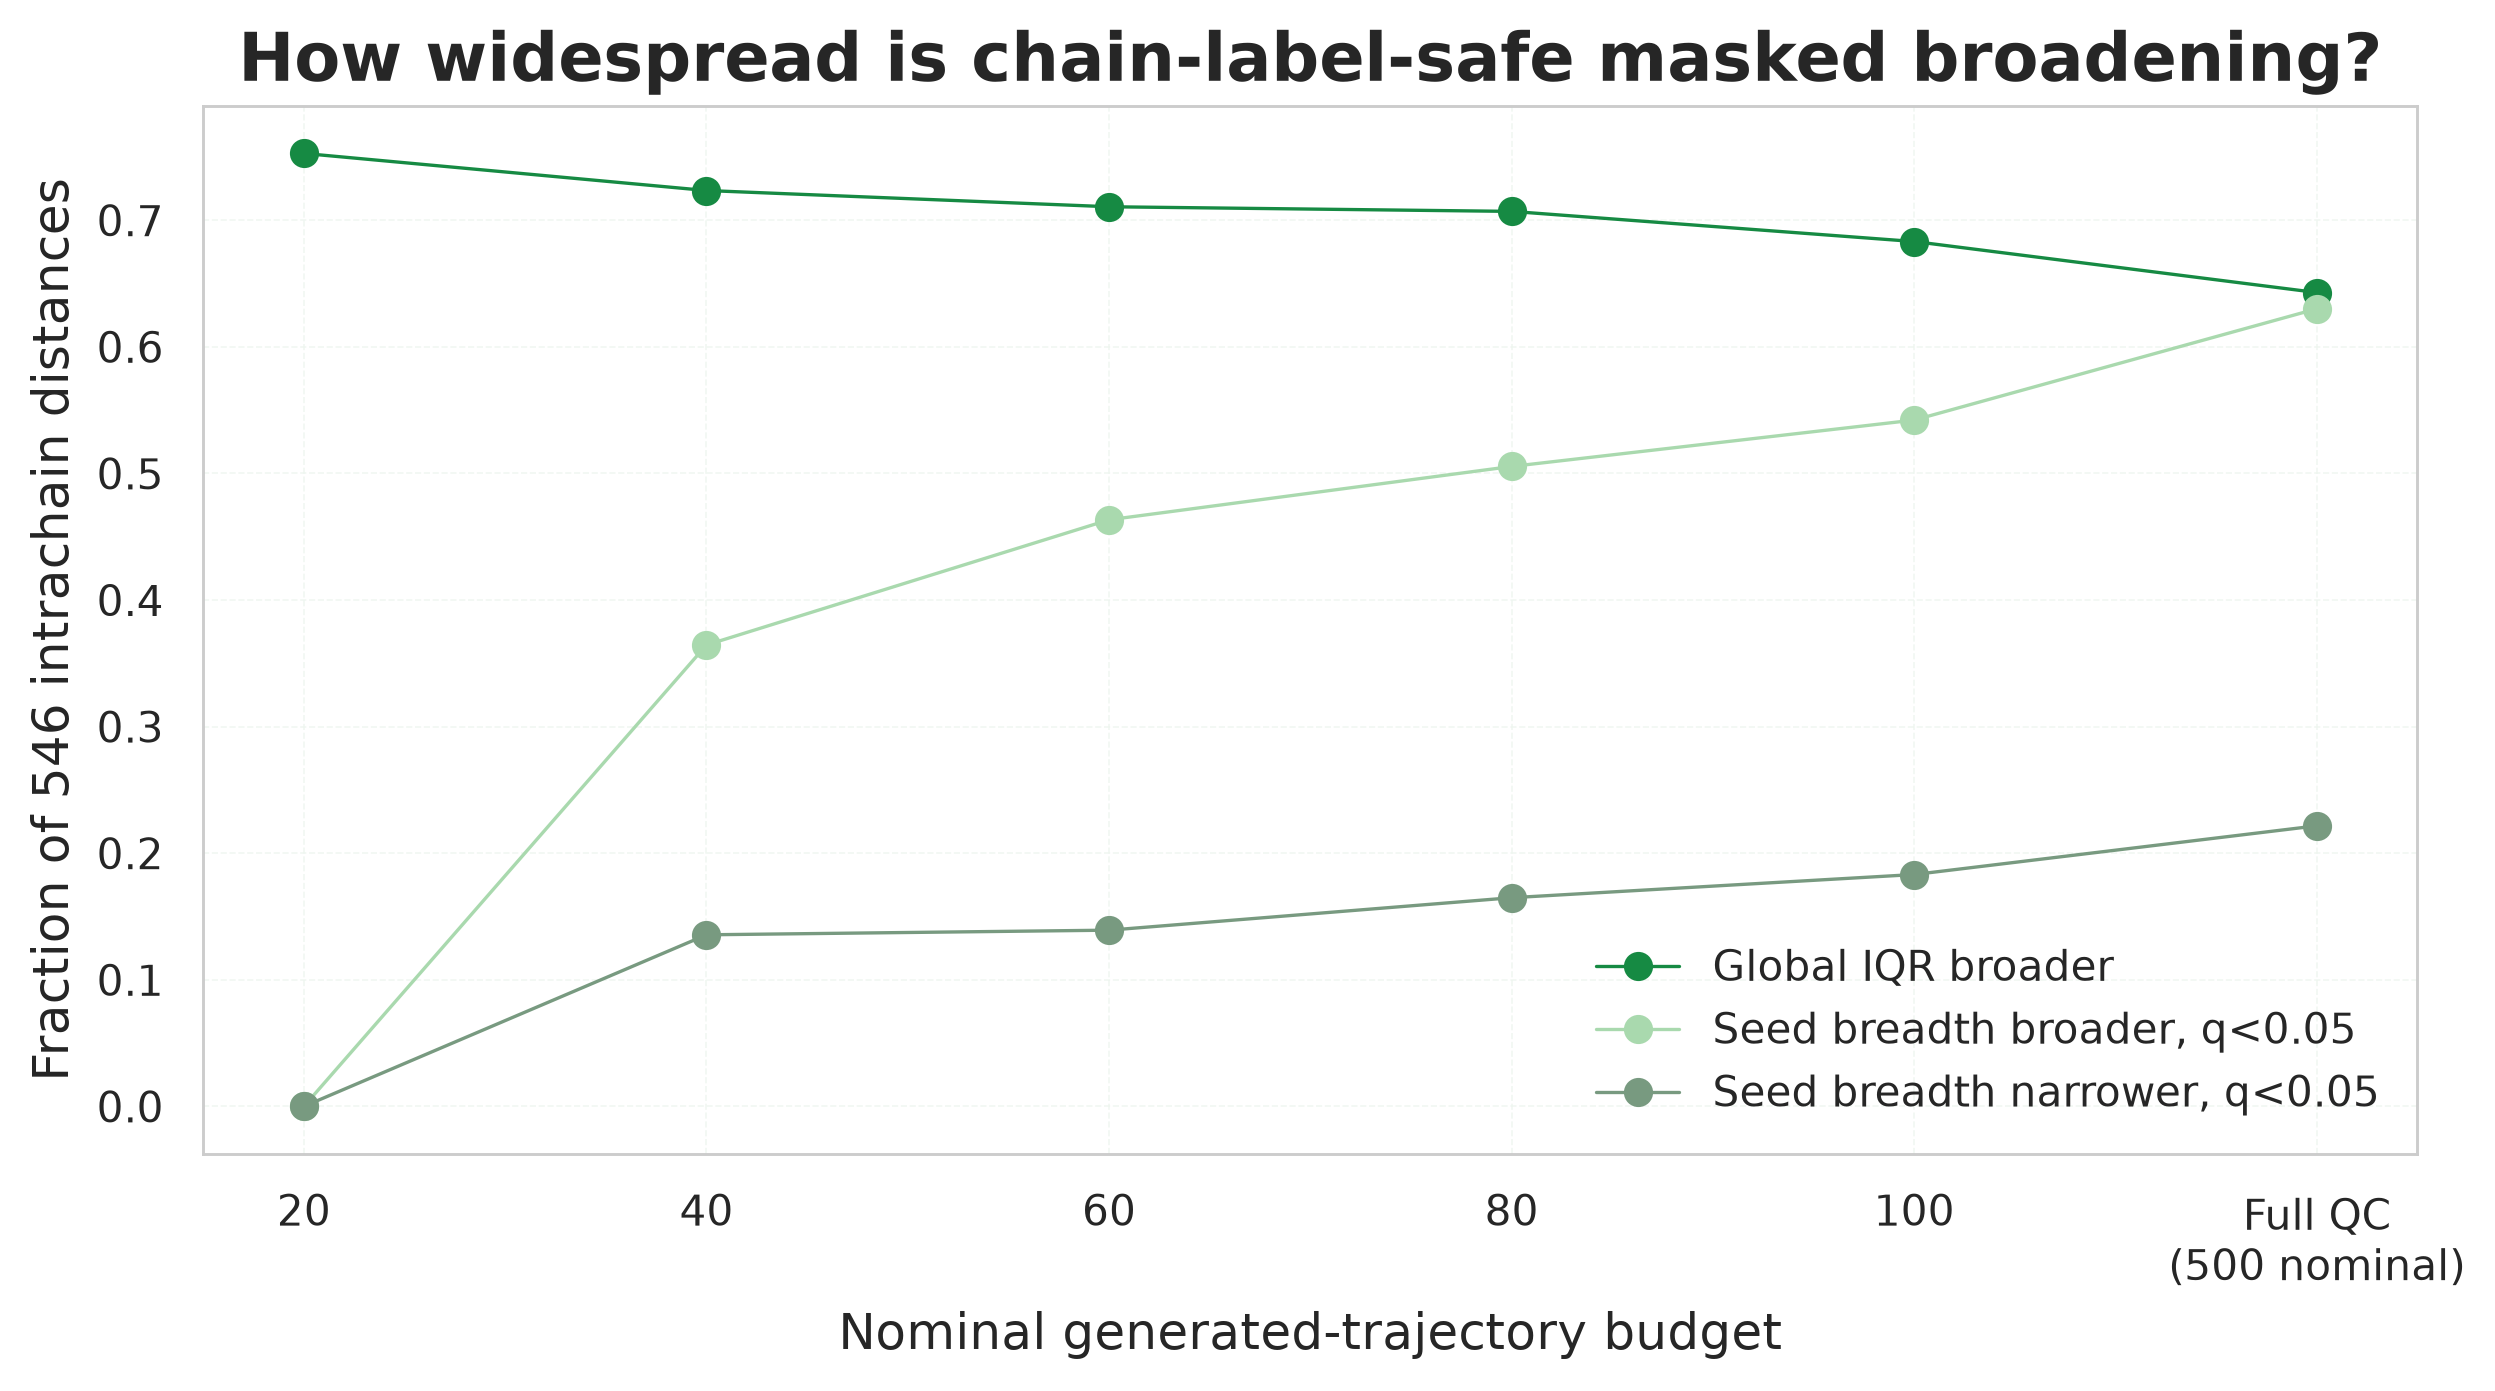

In [3]:
display(pd.read_csv(TAB/'l403a_all_distance_sampling_summary.csv')); display(Image(filename=str(FIG/'all_distance_breadth_fraction_by_depth.png')))

## First 1,000 versus full QC

,depth,metric,spearman_vs_full,p,same_direction_fraction
0,4,global_log2_IQR_ratio,0.871013,4.648754e-170,0.842491
1,4,seed_log2_IQR_ratio,0.694582,7.724610e-80,0.849817
2,4,trajectory_median_W1_A,0.960656,7.791643e-305,NaN
3,8,global_log2_IQR_ratio,0.919884,2.707707e-223,0.873626
4,8,seed_log2_IQR_ratio,0.757414,8.776668e-103,0.866300
5,8,trajectory_median_W1_A,0.948042,9.675193e-273,NaN
6,12,global_log2_IQR_ratio,0.951645,5.157511e-281,0.897436
7,12,seed_log2_IQR_ratio,0.943892,6.507616e-264,0.902930
8,12,trajectory_median_W1_A,0.985276,0.000000e+00,NaN
9,16,global_log2_IQR_ratio,0.951380,2.201662e-280,0.904762


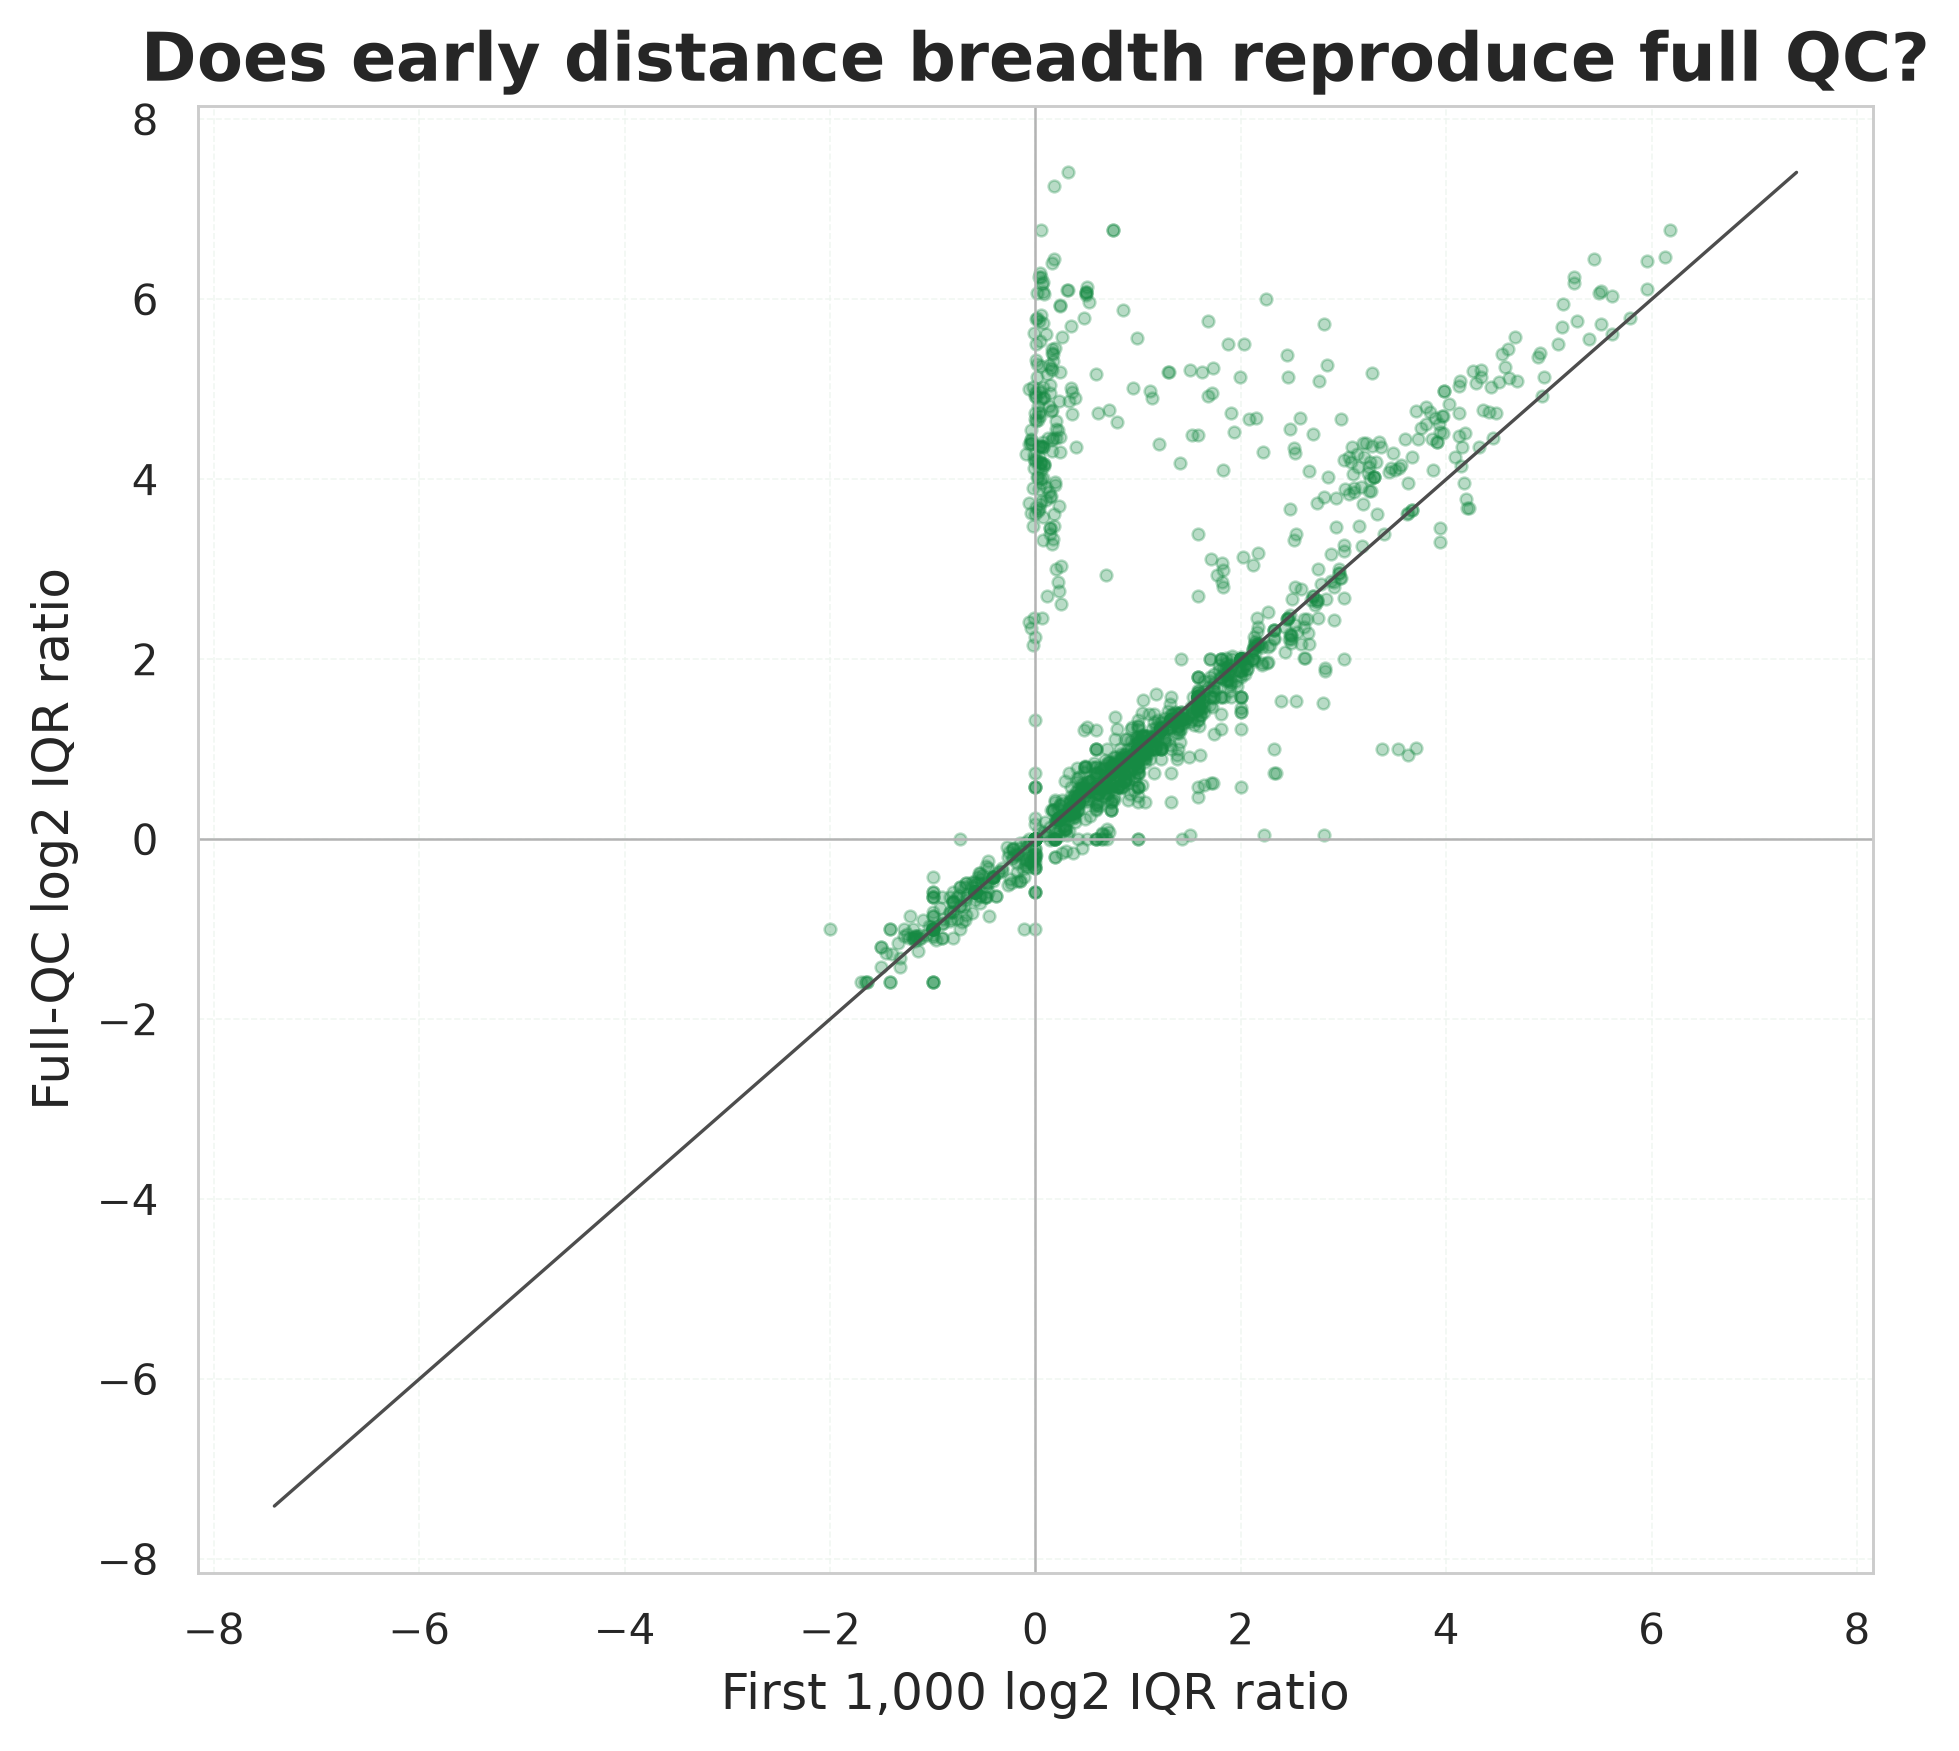

In [4]:
display(pd.read_csv(TAB/'l403a_all_distance_sampling_stability.csv')); display(Image(filename=str(FIG/'first1000_vs_full_distance_breadth.png')))

## Distribution of breadth effects across all 1,410 distances

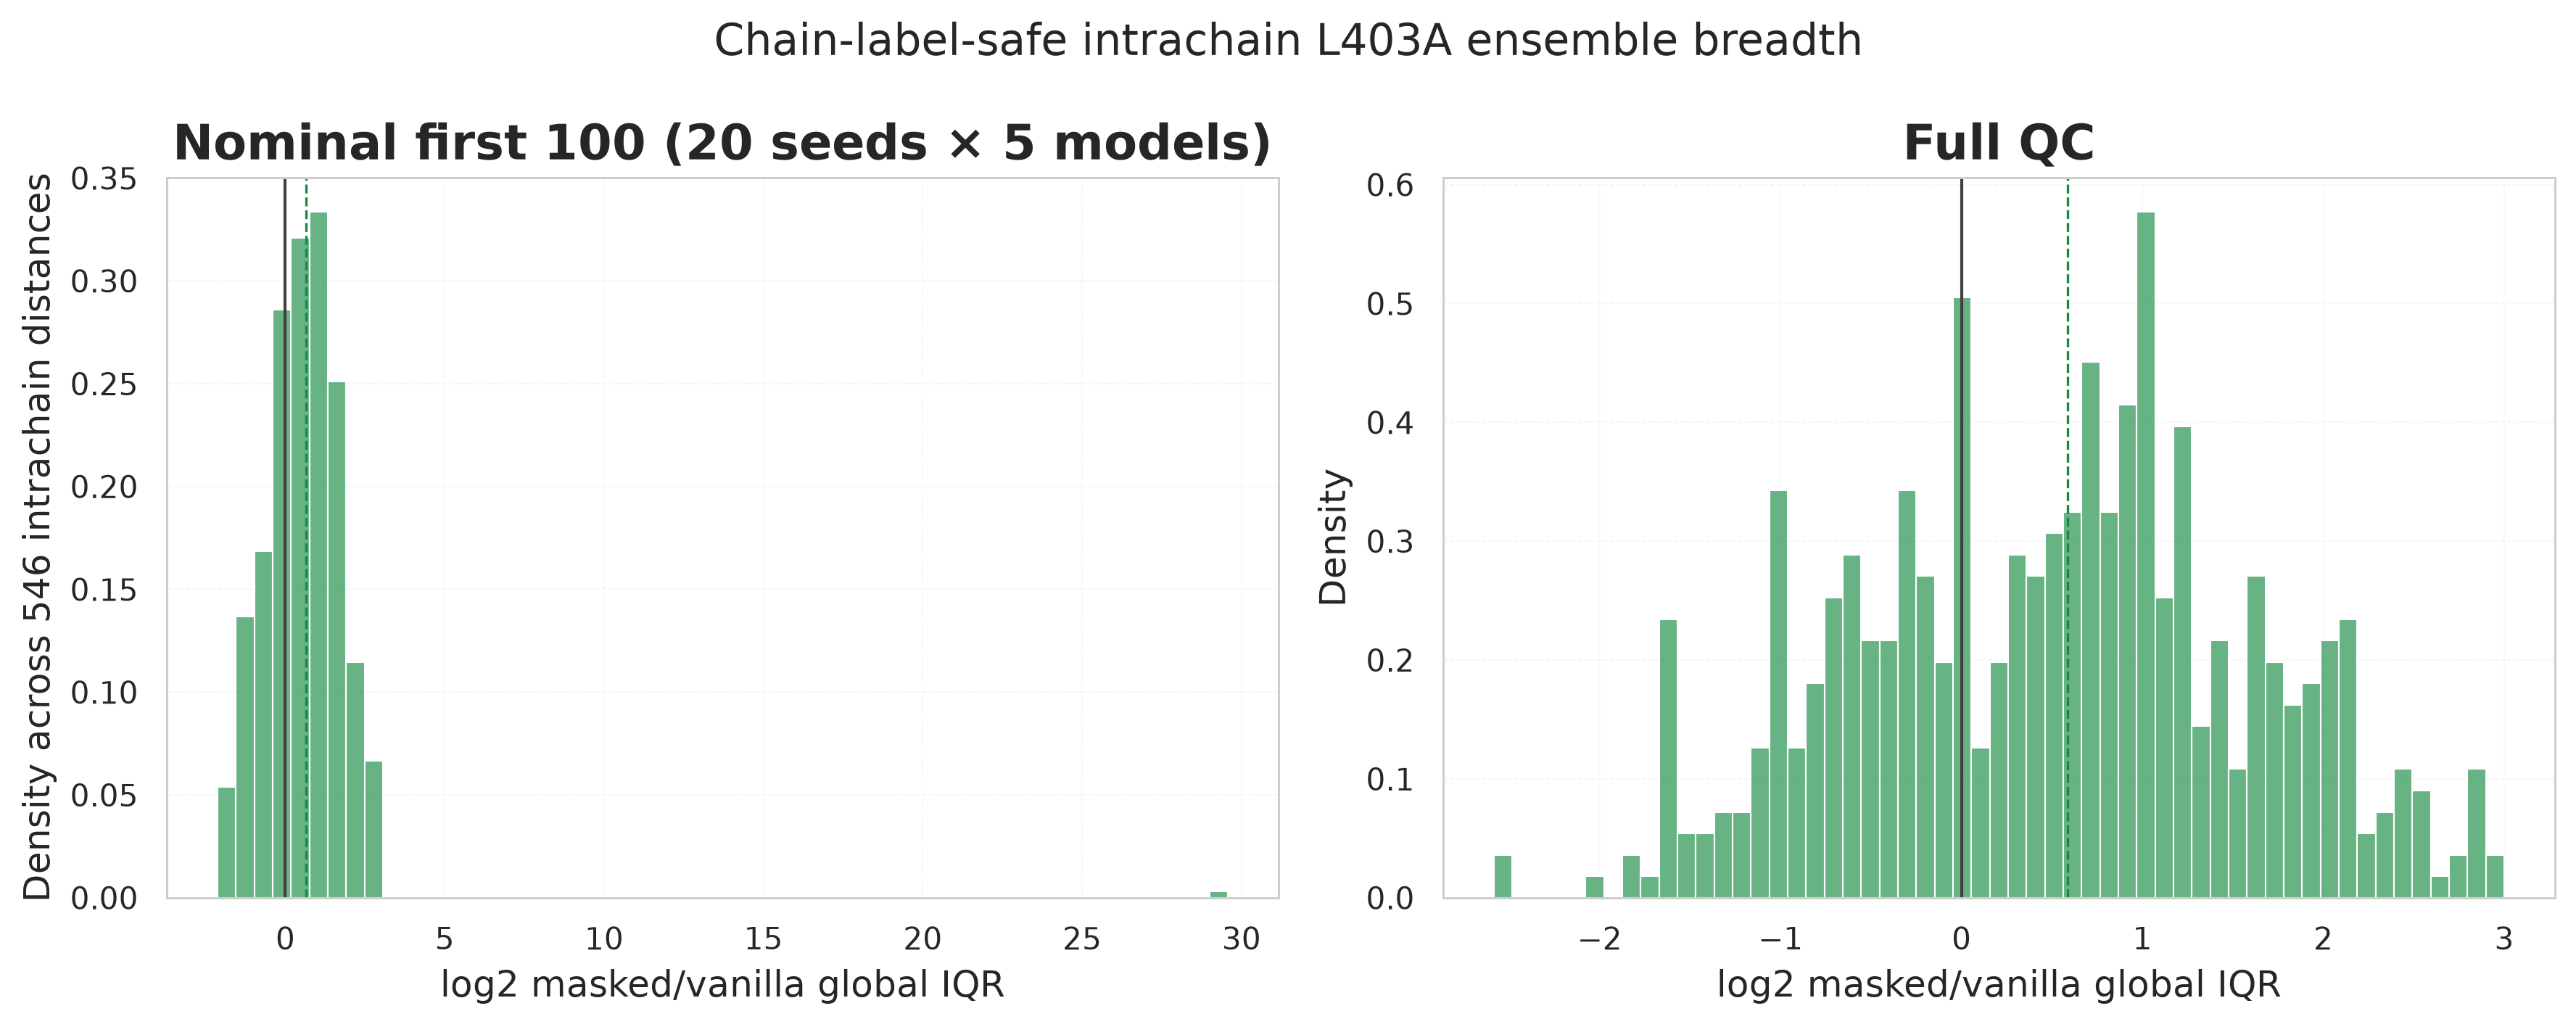

In [5]:
display(Image(filename=str(FIG/'all_distance_iqr_ratio_distributions.png')))

## Strongest concordant broadened and narrowed distances

,distance,global_log2_IQR_ratio_first20seeds,global_log2_IQR_ratio_full,concordant,min_abs
0,CA_CA_B_ARG298_CA-B_PHE238_CA,2.969626,3.000000,True,2.969626
1,shortest_ARG292B-GLU231B,2.807355,2.807355,True,2.807355
2,shortest_ARG292D-GLU231D,2.807355,2.807355,True,2.807355
3,shortest_ARG292A-CYS234A,3.000000,2.807355,True,2.807355
4,CA_CA_A_ARG298_CA-A_PHE238_CA,2.716207,2.938599,True,2.716207
5,CA_CA_D_ARG298_CA-D_PHE238_CA,2.823122,2.716207,True,2.716207
6,CA_CA_C_ARG298_CA-C_PHE238_CA,2.678072,2.747234,True,2.678072
7,CA_CA_B_ARG304_CA-B_CYS234_CA,2.632268,2.632268,True,2.632268
8,shortest_ARG304A-PHE238A,2.700440,2.584962,True,2.584962
9,shortest_ARG304C-PHE238C,2.584962,2.584962,True,2.584962


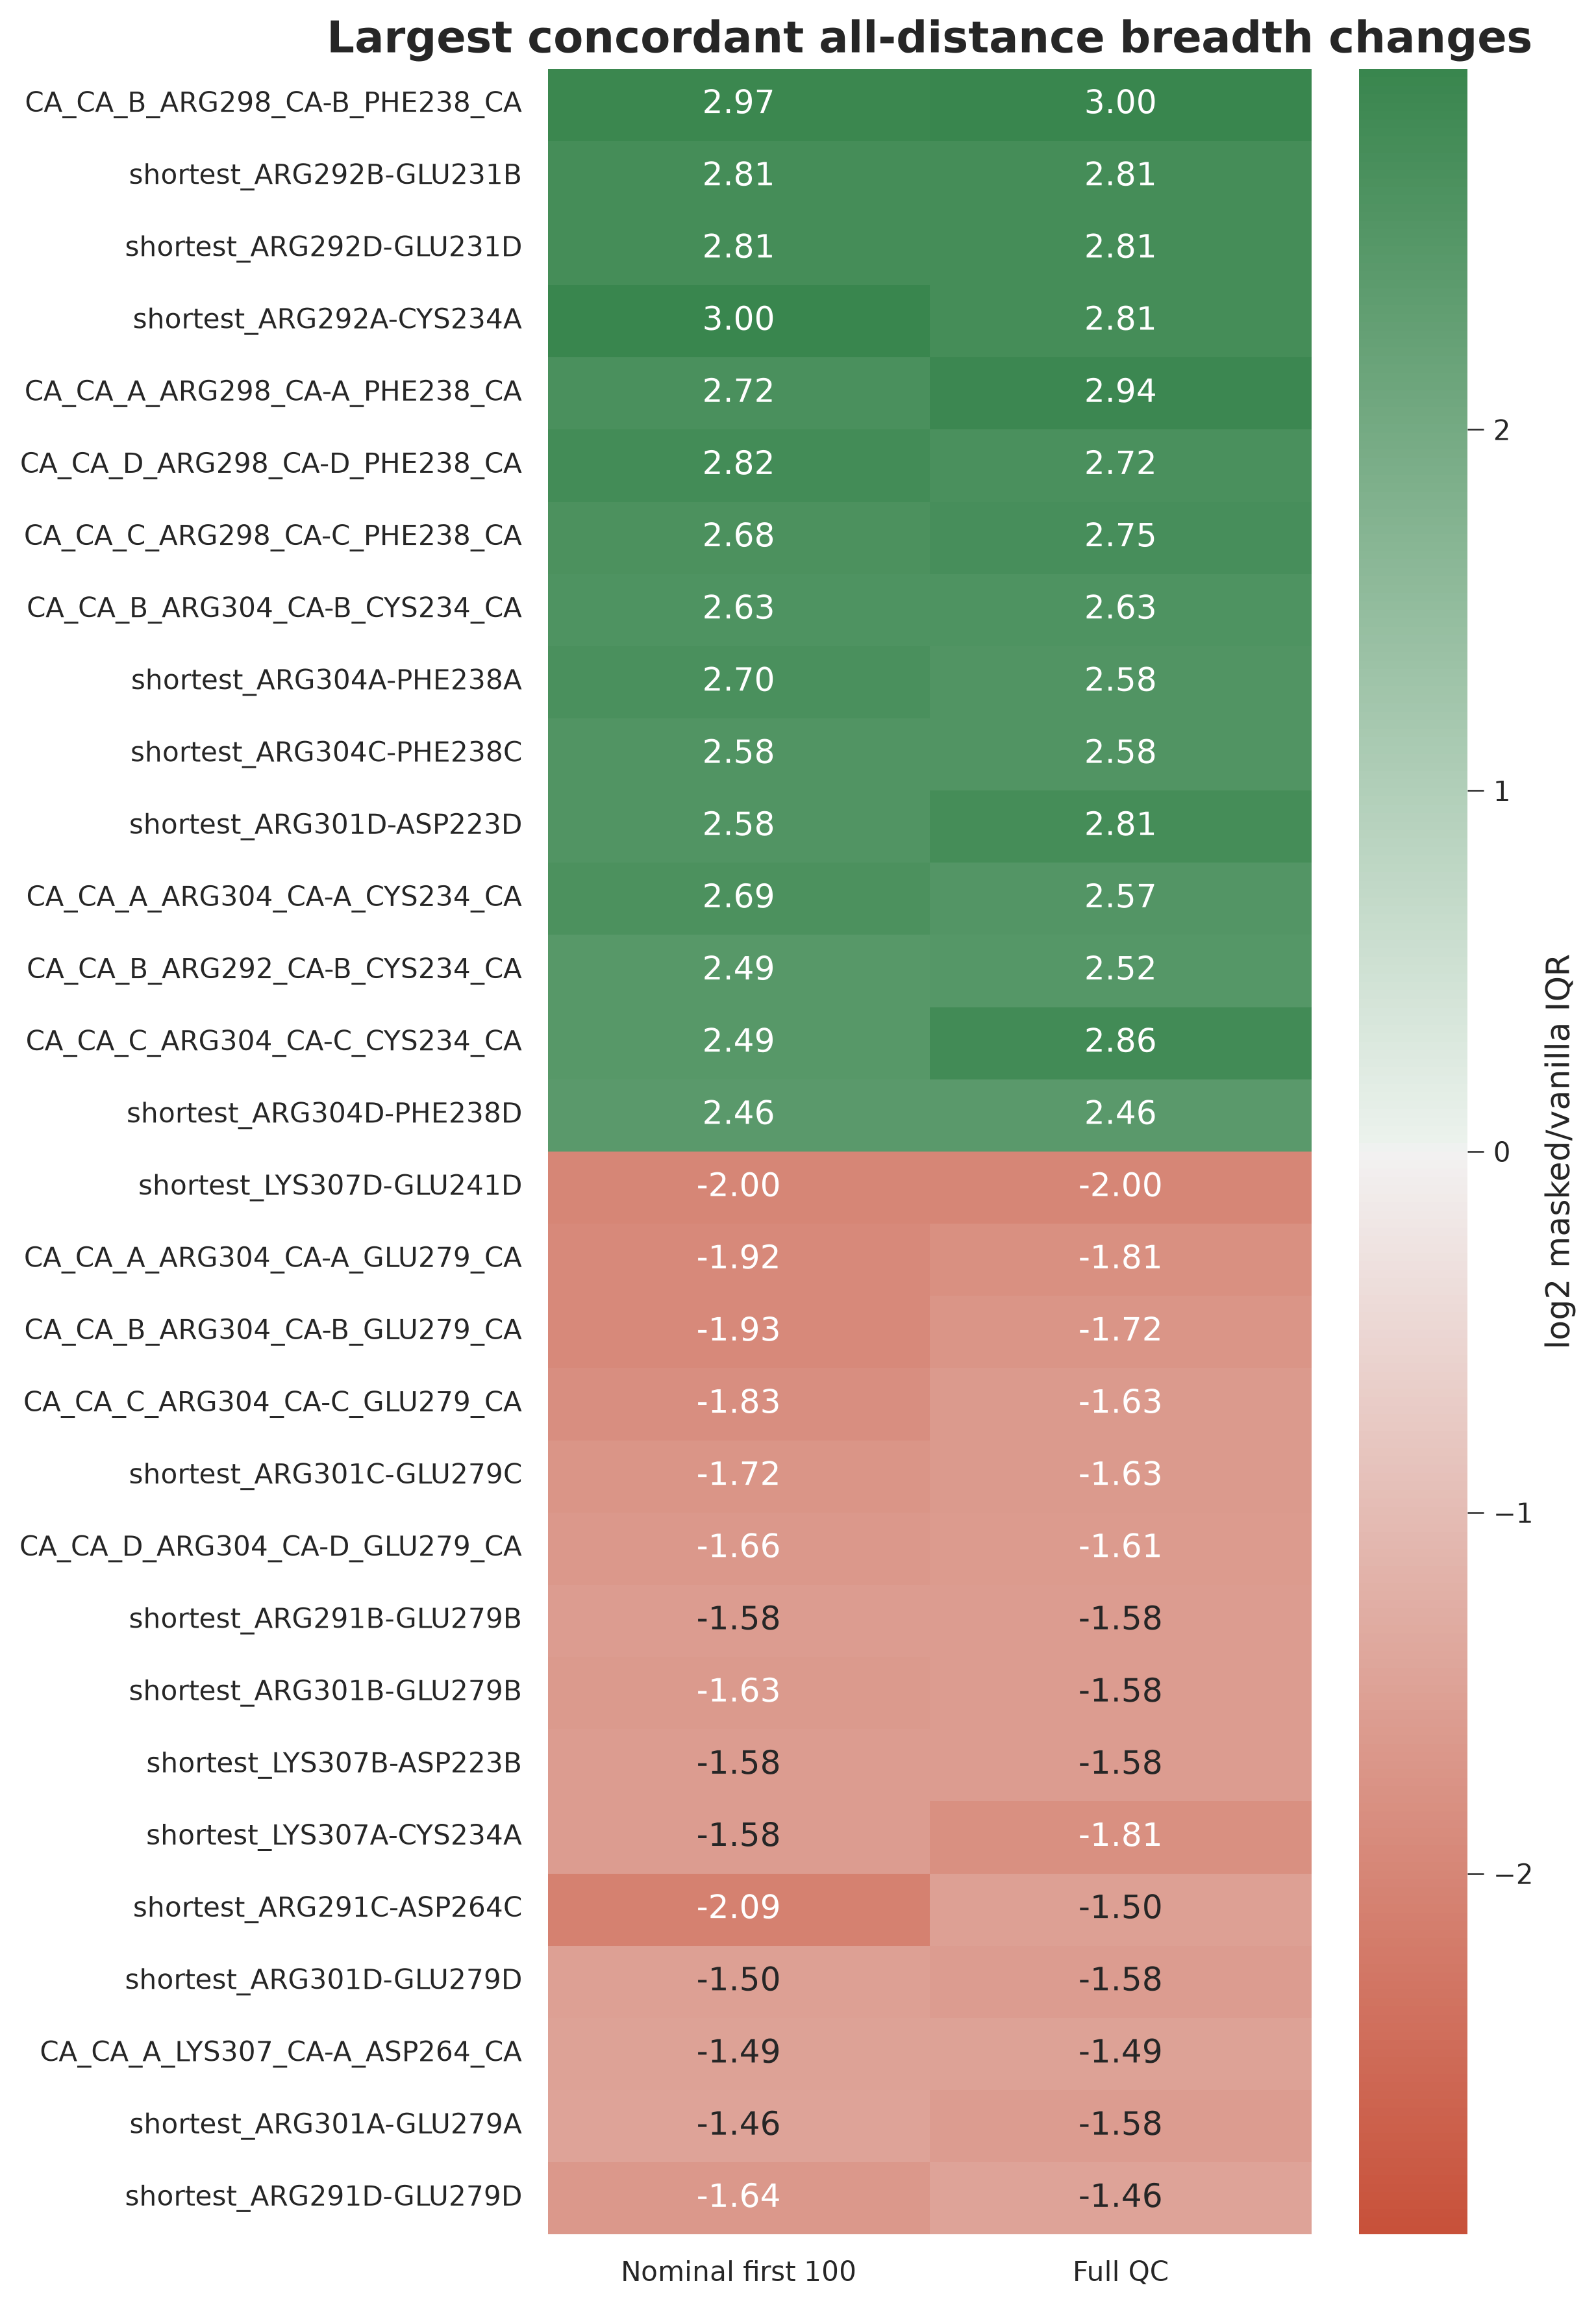

In [6]:
display(pd.read_csv(TAB/'top_concordant_distance_breadth_changes.csv')); display(Image(filename=str(FIG/'top_all_distance_breadth_heatmap.png')))

## Machine-readable distance-level statistics

In [7]:
stats=pd.read_csv(TAB/'l403a_all_distance_sampling_statistics.csv')
display(stats[stats.depth.astype(str).isin(['1000','Full QC'])])
print(f'{len(stats):,} distance-by-depth rows')

,depth,distance,distance_type,vanilla_median_A,masked_median_A,delta_median_A,vanilla_global_IQR_A,masked_global_IQR_A,global_IQR_ratio,global_log2_IQR_ratio,...,brown_forsythe_p,brown_forsythe_q,trajectory_median_W1_A,W1_normalized_pooled_IQR,vanilla_rows,masked_rows,vanilla_seeds,masked_seeds,vanilla_trajectories,masked_trajectories
2730,Full QC,CA_CA_A_ALA405_CA-A_LEU331_CA,CA,9.85,9.91,0.06,0.110,0.0900,0.818182,-0.289507,...,1.770331e-03,2.159328e-03,0.105259,0.809686,479,426,100,100,479,426
2731,Full QC,CA_CA_A_ALA405_CA-A_LEU332_CA,CA,8.30,8.40,0.10,0.105,0.0900,0.857143,-0.222392,...,1.325565e-04,1.692741e-04,0.147146,1.226217,479,426,100,100,479,426
2732,Full QC,CA_CA_A_ALA405_CA-A_PHE335_CA,CA,9.60,9.71,0.11,0.100,0.1100,1.100000,0.137504,...,1.679372e-09,2.602788e-09,0.124356,0.956584,479,426,100,100,479,426
2733,Full QC,CA_CA_A_ARG291_CA-A_ASP223_CA,CA,14.38,14.60,0.22,0.480,0.6775,1.411458,0.497187,...,1.564463e-23,3.765787e-23,0.267558,0.405391,479,426,100,100,479,426
2734,Full QC,CA_CA_A_ARG291_CA-A_ASP264_CA,CA,24.84,25.02,0.18,0.130,0.1775,1.365385,0.449307,...,3.934592e-02,4.449934e-02,0.161538,0.621301,479,426,100,100,479,426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3271,Full QC,shortest_PHE414C-LEU322C,shortest_heavy,10.00,10.00,0.00,0.200,0.3000,1.500000,0.584962,...,4.909303e-05,6.450872e-05,0.271746,1.358729,479,426,100,100,479,426
3272,Full QC,shortest_PHE414D-LEU315D,shortest_heavy,8.60,8.50,-0.10,0.200,0.4750,2.375000,1.247928,...,1.382458e-09,2.148735e-09,0.172746,0.863730,479,426,100,100,479,426
3273,Full QC,shortest_PHE414D-LEU318D,shortest_heavy,5.50,5.40,-0.10,0.200,0.2000,1.000000,0.000000,...,9.930175e-04,1.222175e-03,0.118656,0.593282,479,426,100,100,479,426
3274,Full QC,shortest_PHE414D-LEU322D,shortest_heavy,10.00,10.00,0.00,0.200,0.2000,1.000000,0.000000,...,1.677864e-04,2.122693e-04,0.254769,1.273844,479,426,100,100,479,426


3,276 distance-by-depth rows


## Manuscript-facing uncertainty audit

In [8]:
from analysis.statistics_revision.scripts.run_kv21_sampling_breadth_uncertainty import run as run_uncertainty
run_uncertainty()
revision_tables=repo_root/'analysis'/'statistics_revision'/'tables'
display(pd.read_csv(TAB/'l403a_first100_seed_level_global_breadth_summary.csv'))
display(pd.read_csv(revision_tables/'kv21_s6_masked_vs_vanilla_breadth_bootstrap.csv'))
display(pd.read_csv(revision_tables/'kv21_rmsf_trajectory_block_bootstrap.csv'))
display(pd.read_csv(revision_tables/'kv21_sampling_breadth_manuscript_statistics.csv'))

{
  "first100_ratio_summary": "/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataExtra/conformation_analysis/all_distance_sampling/tables/l403a_first100_seed_level_global_breadth_summary.csv",
  "s6_all_reported_values_reproduced": false,
  "s6_bootstrap_status": "blocked because original point estimates were not reproduced",
  "rmsf_bootstrap_status": "completed from aligned C-alpha arrays with trajectory-block resampling"
}
sequence_background  reported_median_SD_ratio  closest_current_reproducible_median_SD_ratio  representative_only_median_SD_ratio  reported_value_reproduced                                bootstrap_status  bootstrap_median_ratio  bootstrap_95CI_low  bootstrap_95CI_high  fraction_bootstrap_ratio_gt_1  bootstrap_replicates  bootstrap_seed
                 WT                      3.50                                      2.848771                             3.067562                      False blocked: original point estimate not reproduced                  

,vanilla_seeds,masked_seeds,vanilla_median_normalized_seed_IQR,masked_median_normalized_seed_IQR,masked_over_vanilla_median_ratio,median_difference_masked_minus_vanilla,bootstrap_95CI_difference_low,bootstrap_95CI_difference_high,bootstrap_95CI_ratio_low,bootstrap_95CI_ratio_high,bootstrap_ratio_replicates,bootstrap_ratio_seed,mannwhitney_U_masked_vs_vanilla,mannwhitney_p_two_sided,rank_biserial_masked_greater
0,20,20,0.535539,0.805123,1.503388,0.269584,0.193028,0.30591,1.342107,1.603285,10000,20260803,397.0,1.064569e-07,0.985


,sequence_background,reported_median_SD_ratio,closest_current_reproducible_median_SD_ratio,representative_only_median_SD_ratio,reported_value_reproduced,bootstrap_status,bootstrap_median_ratio,bootstrap_95CI_low,bootstrap_95CI_high,fraction_bootstrap_ratio_gt_1,bootstrap_replicates,bootstrap_seed
0,WT,3.50,2.848771,3.067562,False,blocked: original point estimate not reproduced,NaN,NaN,NaN,NaN,0,20260803
1,L403A,2.08,1.901599,1.549884,False,blocked: original point estimate not reproduced,NaN,NaN,NaN,NaN,0,20260803
2,F412L,1.92,2.897953,2.532573,False,blocked: original point estimate not reproduced,NaN,NaN,NaN,NaN,0,20260803


,sequence_background,region,observed_median_masked_minus_vanilla_RMSF_A,bootstrap_median_A,bootstrap_95CI_low_A,bootstrap_95CI_high_A,bootstrap_replicates,bootstrap_seed,bootstrap_unit
0,WT,directly_masked_positions,1.467352,1.466091,1.203577,1.732275,10000,20260803,complete model-seed trajectory
1,WT,outside_direct_mask,-0.240177,-0.186130,-0.728088,0.175543,10000,20260803,complete model-seed trajectory
2,L403A,directly_masked_positions,1.307682,1.316377,1.036825,1.582632,10000,20260803,complete model-seed trajectory
3,L403A,outside_direct_mask,-0.395433,-0.377352,-1.040971,0.116338,10000,20260803,complete model-seed trajectory
4,F412L,directly_masked_positions,1.306238,1.311206,1.117422,1.507174,10000,20260803,complete model-seed trajectory
5,F412L,outside_direct_mask,-0.472332,-0.464234,-0.840170,-0.011465,10000,20260803,complete model-seed trajectory


,section,metric,vanilla_seeds,masked_seeds,vanilla_median_normalized_seed_IQR,masked_median_normalized_seed_IQR,masked_over_vanilla_median_ratio,median_difference_masked_minus_vanilla,bootstrap_95CI_difference_low,bootstrap_95CI_difference_high,...,bootstrap_95CI_low,bootstrap_95CI_high,fraction_bootstrap_ratio_gt_1,bootstrap_replicates,bootstrap_seed,region,observed_median_masked_minus_vanilla_RMSF_A,bootstrap_median_A,bootstrap_95CI_low_A,bootstrap_95CI_high_A
0,First100 L403A,global normalized seed breadth,20.0,20.0,0.535539,0.805123,1.503388,0.269584,0.193028,0.30591,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,First100 distance-wise breadth,all 546 distances,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Full-depth robustness,all 546 distances,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Random-seed saturation,5 seeds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Random-seed saturation,10 seeds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Random-seed saturation,20 seeds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Random-seed saturation,25 seeds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Random-seed saturation,50 seeds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Random-seed saturation,75 seeds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Random-seed saturation,100 seeds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Reading guide

- `global_IQR_ratio > 1` means the masked raw ensemble is broader for that distance.
- `seed_IQR_ratio > 1` means the typical within-seed masked ensemble is broader.
- `seed_breadth_q < 0.05` identifies FDR-significant protocol differences using seeds as replicates.
- `trajectory_median_W1_A` describes protocol separation after giving each seed/model trajectory one median observation.
- Agreement between first 1,000 and full QC supports sampling-efficiency claims; it does not convert deterministic seed order into chronological time.
- These all-distance results establish breadth, not whether broader states are experimentally correct.